# Graph One NetCDF File

Use this notebook when you want plots for one specific `.nc` file from `outputs/weekend_nc` or any explicit NetCDF path.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image, display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)

REPO_ROOT = Path.cwd()
GRID_ROOT = REPO_ROOT / "roadrunner_egp" / "aurora_subneptune_grid"
NC_DIR = REPO_ROOT / "outputs" / "weekend_nc"
OUT_ROOT = REPO_ROOT / "outputs" / "single_nc_graphs"

for extra_path in (GRID_ROOT / "src", GRID_ROOT.parent):
    if str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))

# Change this to a filename like "run_0000877.nc", a relative path, or an absolute path.
SELECTED_NC = "run_0000000.nc"

print(f"Repo root: {REPO_ROOT}")
print(f"Default NetCDF folder: {NC_DIR}")
print(f"Plot output folder: {OUT_ROOT}")

Repo root: /home/u11/danielxinhuang/Documents/aurora
Default NetCDF folder: /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc
Plot output folder: /home/u11/danielxinhuang/Documents/aurora/outputs/single_nc_graphs


In [2]:
def resolve_nc_path(selected: str | Path) -> Path:
    path = Path(selected).expanduser()
    if path.is_absolute():
        resolved = path
    else:
        candidates = [REPO_ROOT / path, NC_DIR / path]
        resolved = next((candidate for candidate in candidates if candidate.exists()), candidates[-1])
    resolved = resolved.resolve()
    if not resolved.exists():
        raise FileNotFoundError(resolved)
    return resolved


def open_dataset_with_help(path: Path) -> xr.Dataset:
    errors: dict[str, str] = {}
    for engine in (None, "netcdf4", "h5netcdf", "scipy"):
        try:
            kwargs = {} if engine is None else {"engine": engine}
            return xr.open_dataset(path, **kwargs)
        except Exception as exc:
            errors[str(engine or "auto")] = f"{type(exc).__name__}: {exc}"
    raise RuntimeError(json.dumps(errors, indent=2))


nc_path = resolve_nc_path(SELECTED_NC)
ds = open_dataset_with_help(nc_path)
plot_dir = OUT_ROOT / nc_path.stem
plot_dir.mkdir(parents=True, exist_ok=True)

print(f"Opened: {nc_path}")
ds

Opened: /home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc/run_0000000.nc


<xarray.Dataset> Size: 3MB
Dimensions:                           (wavelength: 2201, level: 61,
                                       species: 50, layer: 60,
                                       brightness_wavelength_um: 196)
Coordinates:
    wavelength_um                     (wavelength) float64 18kB ...
    wavenumber_cm1                    (wavelength) float64 18kB ...
  * level                             (level) int32 244B 0 1 2 3 ... 57 58 59 60
  * species                           (species) <U5 1kB 'index' 'H2' ... 'C+'
  * layer                             (layer) int32 240B 0 1 2 3 ... 56 57 58 59
    qc_brightness_wavelength_um       (brightness_wavelength_um) float64 2kB ...
Dimensions without coordinates: wavelength, brightness_wavelength_um
Data variables: (12/42)
    reflected_planet_star_flux_ratio  (wavelength) float64 18kB ...
    geometric_albedo                  (wavelength) float64 18kB ...
    reflected_flux                    (wavelength) float64 18kB ...
    thermal_flux                      (wavelength) float64 18kB ...
    pressure_bar                      (level) float64 488B ...
    temperature_k                     (level) float64 488B ...
    ...                                ...
    c_to_o_xsolar                     float64 8B ...
    kzz_cm2_s                         float64 8B ...
    cloud_fraction                    float64 8B ...
    fsed                              float64 8B ...
    run_success                       int8 1B ...
    runtime_seconds                   float64 8B ...
Attributes: (12/27)
    title:                      AURORA sub-Neptune reflected-light model run
    schema_name:                aurora_subneptune_netcdf
    schema_version:             1.0
    model_name:                 hpc_validation_aurora_subneptune
    run_id:                     25169bb23781
    created_utc:                2026-06-19T23:38:31.698758Z
    ...                         ...
    schema_warnings:            ["star_mass_msun unavailable; stored NaN", "s...
    netcdf_optional_variables:  []
    netcdf_strict_optional:     False
    climate_converged:          1
    climate_opacity_method:     preweighted
    selected_ck_file:           /home/u11/danielxinhuang/Documents/aurora/pic...

In [3]:
def finite_min_max(da: xr.DataArray) -> tuple[float | None, float | None]:
    try:
        values = np.asarray(da.values, dtype=float)
    except Exception:
        return None, None
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return None, None
    return float(np.nanmin(finite)), float(np.nanmax(finite))


rows = []
for name in list(ds.coords) + list(ds.data_vars):
    da = ds[name]
    min_value, max_value = finite_min_max(da)
    rows.append(
        {
            "name": name,
            "kind": "coord" if name in ds.coords else "data_var",
            "dims": ", ".join(da.dims),
            "shape": da.shape,
            "dtype": str(da.dtype),
            "units": da.attrs.get("units", ""),
            "description": da.attrs.get("description", da.attrs.get("long_name", "")),
            "min": min_value,
            "max": max_value,
        }
    )

var_table = pd.DataFrame(rows)
display(var_table)

,name,kind,dims,shape,dtype,units,description,min,max
0,wavelength_um,coord,wavelength,"(2201,)",float64,um,,3.000000e-01,2.500000e+00
1,wavenumber_cm1,coord,wavelength,"(2201,)",float64,cm^-1,,4.000000e+03,3.333333e+04
2,level,coord,level,"(61,)",int32,index,,0.000000e+00,6.000000e+01
3,layer,coord,layer,"(60,)",int32,index,,0.000000e+00,5.900000e+01
4,species,coord,species,"(50,)",<U5,,,NaN,NaN
5,qc_brightness_wavelength_um,coord,brightness_wavelength_um,"(196,)",float64,um,Native wavelength grid for the exact PICASO brightness-temperature diagnostic.,2.678680e-01,2.275313e+02
6,reflected_planet_star_flux_ratio,data_var,wavelength,"(2201,)",float64,dimensionless,Reflected-light planet/star flux ratio.,1.593953e-12,1.299471e-07
7,geometric_albedo,data_var,wavelength,"(2201,)",float64,dimensionless,Geometric albedo spectrum.,8.573898e-06,6.989874e-01
8,reflected_flux,data_var,wavelength,"(2201,)",float64,erg cm-2 s-1 um-1,Absolute reflected planet flux diagnostic converted from Roadrunner/PICASO output to per-micron wavelength units.,1.745581e-03,3.016323e+02
9,thermal_flux,data_var,wavelength,"(2201,)",float64,erg cm-2 s-1 um-1,Absolute thermal planet flux diagnostic converted from Roadrunner/PICASO output to per-micron wavelength units. Only valid if the therma...,8.374853e-09,3.115551e+03


## Built-In Aurora QC Plots

QC status: pass (pass)
Diagnostic plot: /home/u11/danielxinhuang/Documents/aurora/outputs/single_nc_graphs/run_0000000/run_0000000_diagnostic.png
Spectrum plot: /home/u11/danielxinhuang/Documents/aurora/outputs/single_nc_graphs/run_0000000/run_0000000_spectrum.png


,value
run_index,0
run_id,25169bb23781
file_path,/home/u11/danielxinhuang/Documents/aurora/outputs/weekend_nc/run_0000000.nc
status,pass
storage_level,aurora_schema_v1
severity,pass
fail_reasons,
warning_reasons,
rerun_recommended,False
has_wavelength,True


No QC flags for this file.


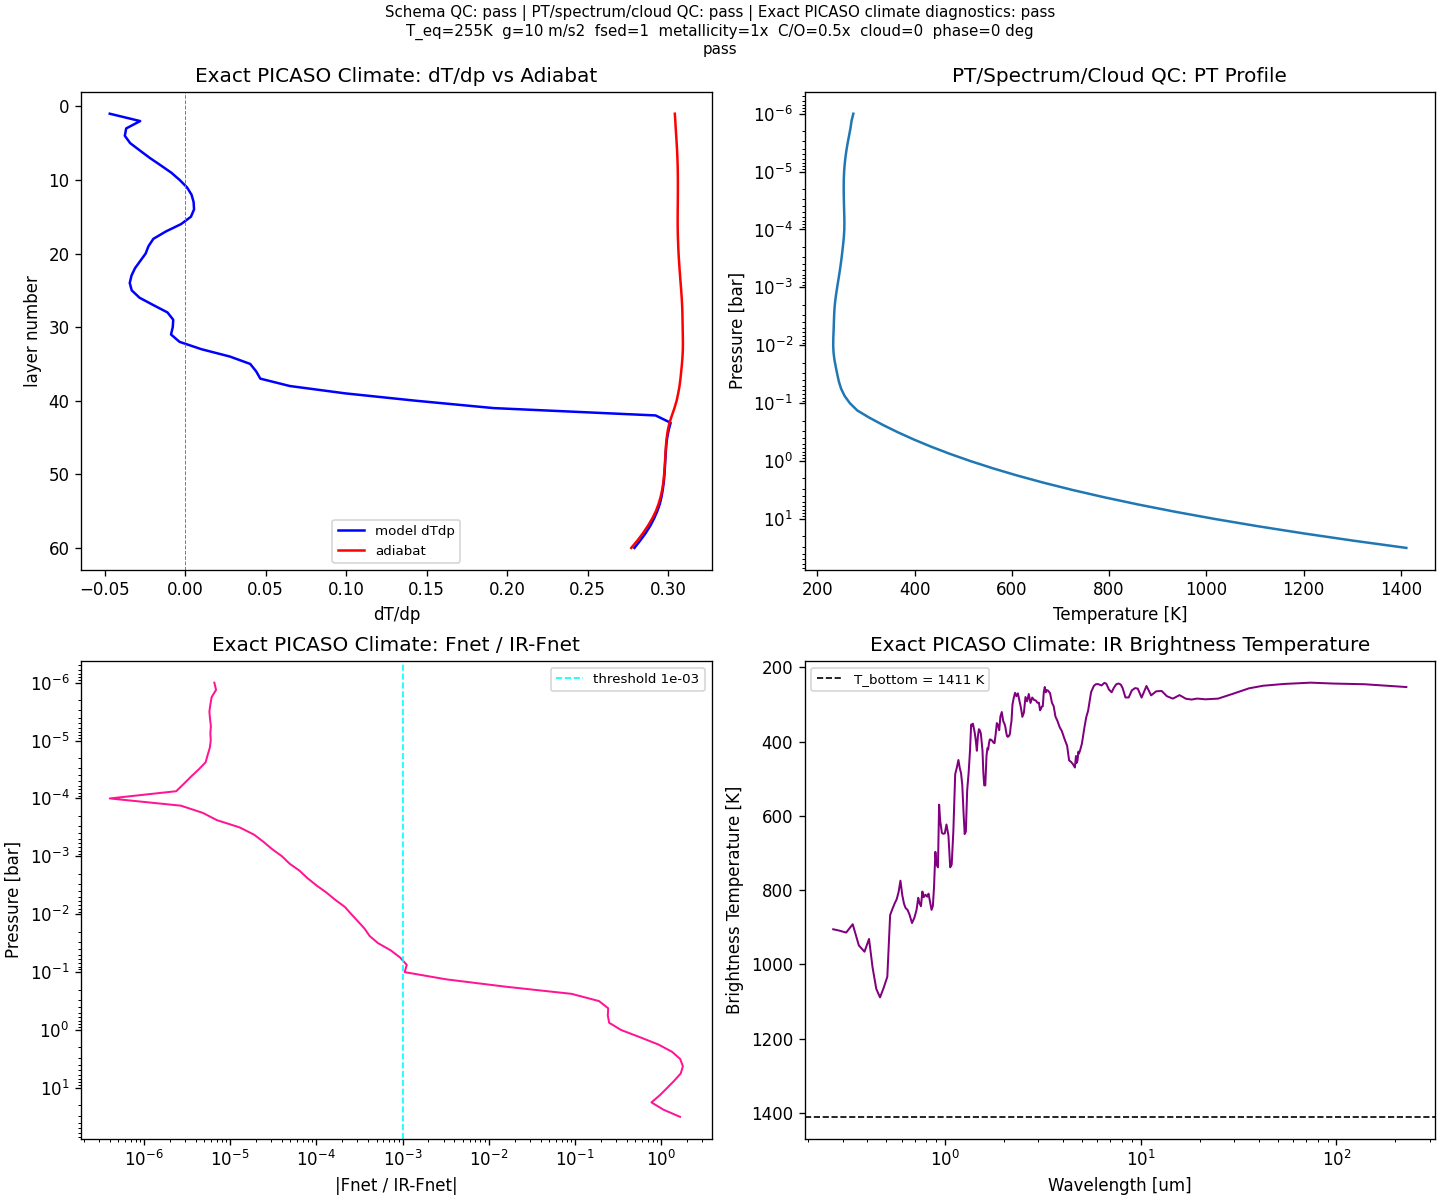

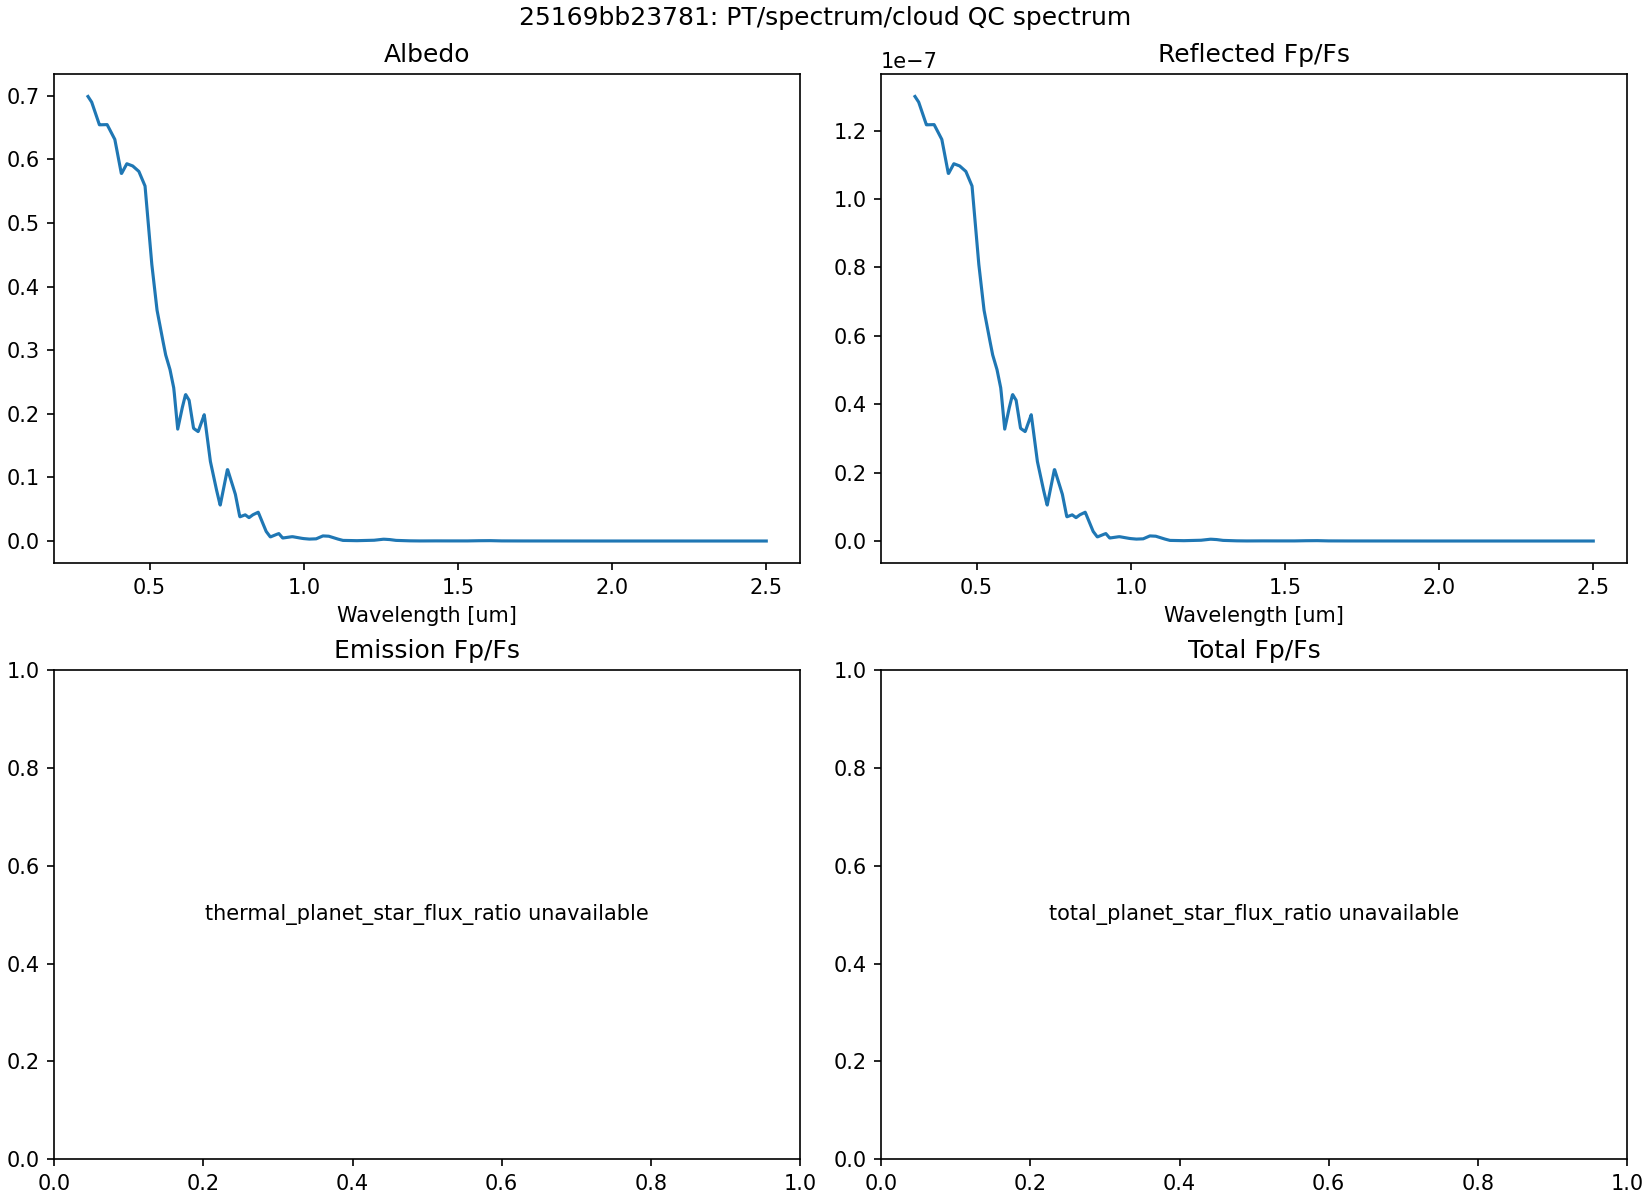

In [4]:
from aurora_grid.qc.plots import make_qc_plot, make_spectrum_plot
from aurora_grid.qc.report import result_to_row, validate_dataset

qc_result = validate_dataset(ds, nc_path)
qc_row = result_to_row(qc_result, ds)
qc_summary = pd.DataFrame([qc_row]).T.rename(columns={0: "value"})

diagnostic_png = make_qc_plot(ds, qc_result, plot_dir / f"{nc_path.stem}_diagnostic.png")
spectrum_png = make_spectrum_plot(ds, qc_result, plot_dir / f"{nc_path.stem}_spectrum.png")

print(f"QC status: {qc_result.status} ({qc_result.severity})")
print(f"Diagnostic plot: {diagnostic_png}")
print(f"Spectrum plot: {spectrum_png}")
display(qc_summary)

if qc_result.flags:
    display(pd.DataFrame([flag.__dict__ for flag in qc_result.flags]))
else:
    print("No QC flags for this file.")

display(Image(filename=str(diagnostic_png)))
display(Image(filename=str(spectrum_png)))

## Plot Any 1D Variable

In [5]:
def choose_wavelength_name(dataset: xr.Dataset) -> str | None:
    for candidate in ["wavelength_um", "wavelength", "wave", "wno", "wavenumber"]:
        if candidate in dataset:
            return candidate
    for name in list(dataset.coords) + list(dataset.data_vars):
        if "wavelength" in name.lower():
            return name
    return None


def plottable_1d_vars(dataset: xr.Dataset, x_name: str | None) -> list[str]:
    names = []
    for name, da in dataset.data_vars.items():
        if da.ndim == 1 and (x_name is None or da.sizes.get(x_name) == dataset[x_name].size):
            names.append(name)
    return names


X_VAR = choose_wavelength_name(ds)
plot_vars = plottable_1d_vars(ds, X_VAR)
preferred = [name for name in plot_vars if any(token in name.lower() for token in ["flux", "albedo", "contrast", "spectrum", "brightness"])]
Y_VAR = preferred[0] if preferred else (plot_vars[0] if plot_vars else None)

print(f"X_VAR = {X_VAR!r}")
print(f"Y_VAR = {Y_VAR!r}")
print(plot_vars)

X_VAR = 'wavelength_um'
Y_VAR = None
[]


In [6]:
# Edit X_VAR and Y_VAR above or here, then rerun this cell.
if X_VAR is None or Y_VAR is None:
    print("No default 1D variables found. Pick variables from var_table manually.")
else:
    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    ax.plot(ds[X_VAR].values, ds[Y_VAR].values, lw=1.8)
    ax.set_xlabel(f"{X_VAR} ({ds[X_VAR].attrs.get('units', '')})".strip())
    ax.set_ylabel(f"{Y_VAR} ({ds[Y_VAR].attrs.get('units', '')})".strip())
    ax.set_title(f"{nc_path.name}: {Y_VAR}")
    ax.grid(True, alpha=0.3)
    out_png = plot_dir / f"{nc_path.stem}_{Y_VAR}.png"
    fig.savefig(out_png, dpi=150)
    print(f"Saved: {out_png}")
    plt.show()

No default 1D variables found. Pick variables from var_table manually.


In [7]:
# Close the open dataset when finished.
ds.close()